<a href="https://colab.research.google.com/github/ThamilarrasiT/Random-forest/blob/main/Random__Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/iris.csv')
display(df.head())
display(df['species'].value_counts())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



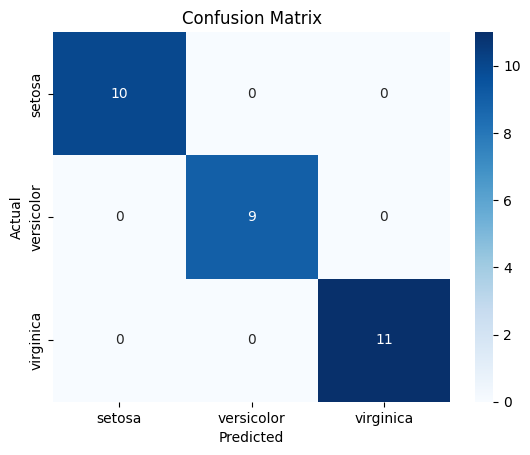

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

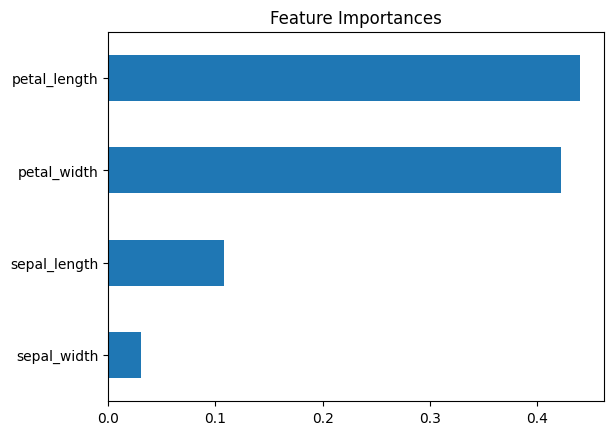

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importances")
plt.show()

In [1]:
data = [
    [1.4, "setosa"],
    [1.3, "setosa"],
    [4.5, "versicolor"],
    [4.1, "versicolor"],
    [5.1, "virginica"],
    [5.4, "virginica"]
]
train = data[:4]
test = data[4:]
predictions = []
for row in test:
    length = row[0]
    if length < 2.0:
        predictions.append("setosa")
    elif length < 5.0:
        predictions.append("versicolor")
    else:
        predictions.append("virginica")
actual = [row[1] for row in test]
correct = 0
for i in range(len(actual)):
    if actual[i] == predictions[i]:
        correct += 1
print("Actual:", actual)
print("Predicted:", predictions)
print("Accuracy:", correct / len(actual))


Actual: ['virginica', 'virginica']
Predicted: ['virginica', 'virginica']
Accuracy: 1.0
